# Dự báo sinh viên bỏ học bằng LightGBM — từ dữ liệu `Testkhoa.csv`

> hành trình
> khoa học dữ liệu: *nhìn dữ liệu thô* → *làm sạch* → *hiểu quy luật* → *xây đặc trưng* →
> *huấn luyện & so sánh mô hình* → *kiểm định độ tin cậy* → *giải thích nguyên nhân* → *đề xuất hệ thống cảnh báo*.

---

### Ba câu hỏi khoa học notebook trả lời
1. **Dự báo được không, sớm tới đâu?** — Chỉ với điểm học kỳ 1, ta cảnh báo được sinh viên nguy cơ bỏ học chưa?
2. **Kết quả có đáng tin không?** — Mô hình có thật sự hơn phương pháp truyền thống, có ổn định theo thời gian và công bằng giữa các nhóm?
3. **Vì sao sinh viên bỏ học?** — Yếu tố nào đẩy nguy cơ lên cao, và ta can thiệp thế nào?

### Bản đồ thư mục (mọi thứ notebook dùng đều ở đây)
| Thư mục | Nội dung |
|---|---|
| `Testkhoa.csv` (gốc) | Dữ liệu thật: 7.514 sinh viên khóa 2020–2021 (đã loại 9 hồ sơ ngoài hai khóa) |
| `dropout_research.py` (gốc) | Khung phân tích: nạp dữ liệu, đặc trưng, mô hình, kiểm định |
| `05_KetQua_ThongKe/` | Bảng kết quả có khoảng tin cậy (CSV) |
| `06_TrungGian_Checkpoint/` | Checkpoint kết quả nặng (tính sẵn, nạp nhanh) |
| `03_KetQua_Hinh/nang_cap_thong_ke/` | Hình xuất bản của phần nâng cấp thống kê |
| `01_DeAn_BaoCao/research_upgrade_report.md` | Báo cáo chi tiết 9 nâng cấp |

*Dữ liệu Việt Nam (`Testkhoa.csv`) là thật; khung đa quốc gia / Lào dùng dữ liệu mô phỏng để minh họa mở rộng.*


## Bước 0 — Chuẩn bị môi trường

Nạp thư viện và **khung phân tích** `dropout_research.py` (ở gốc thư mục). Toàn bộ logic khoa học —
đọc latin-1, dựng đặc trưng theo *tầm nhìn thời gian*, dựng LightGBM xử lý được giá trị thiếu và biến phân loại —
nằm trong module này để notebook gọn và tái lập được.

Cờ `RECOMPUTE=False`: bước nhẹ (nạp, làm sạch, đặc trưng, bằng chứng rò rỉ) **tính trực tiếp**;
bước nặng (nested CV, hiệu chỉnh xác suất, SHAP) **nạp checkpoint** để chạy nhanh.


In [1]:
import os, pickle, warnings
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

import dropout_research as dr   # khung phân tích ở gốc thư mục

CKPT = '06_TrungGian_Checkpoint'
TAB  = '05_KetQua_ThongKe'
FIGS = '03_KetQua_Hinh/nang_cap_thong_ke'
RECOMPUTE = False
RANDOM_STATE = dr.RANDOM_STATE

def load_ckpt(name):
    with open(os.path.join(CKPT, name), 'rb') as fh: return pickle.load(fh)
def load_tab(name):
    return pd.read_csv(os.path.join(TAB, name))

# --- style xuất bản (nhúng sẵn để notebook tự chạy độc lập) ---
META_GREY = '#888888'
def apply_figure_style():
    mpl.rcParams.update({
        'font.size':9,'axes.labelsize':9,'axes.titlesize':9,'legend.fontsize':8,
        'xtick.labelsize':8,'ytick.labelsize':8,'axes.linewidth':0.6,
        'xtick.direction':'out','ytick.direction':'out',
        'axes.spines.top':False,'axes.spines.right':False,
        'legend.frameon':False,'figure.dpi':110,'savefig.dpi':300,
        'savefig.bbox':'tight','axes.titlelocation':'left','lines.linewidth':1.3,
    })
apply_figure_style()

print('Khung tầm nhìn:', dr.SCOPES)
print('RANDOM_STATE =', RANDOM_STATE, '| RECOMPUTE =', RECOMPUTE)
print('Sẵn sàng: HK1 (cảnh báo sớm) · HK1-2 (triển khai) · Đầy đủ (tham chiếu rò rỉ).')


Khung tầm nhìn: {'HK1': 1, 'HK1-2': 2, 'Đầy đủ (4HK, tham chiếu)': 4}
RANDOM_STATE = 42 | RECOMPUTE = False
Sẵn sàng: HK1 (cảnh báo sớm) · HK1-2 (triển khai) · Đầy đủ (tham chiếu rò rỉ).


## Bước 1 — Nạp và làm quen với `Testkhoa.csv`

Câu chuyện bắt đầu bằng việc *nhìn thẳng vào dữ liệu thô*. File lưu mã hóa **latin-1** (ký tự tiếng Việt),
nên phải đọc đúng bảng mã. Mỗi dòng là **một sinh viên**; các cột chia ba nhóm tự nhiên:

- **Nhân khẩu học** — giới tính, dân tộc, vùng miền, năm nhập học…
- **Đầu vào** — điểm/thứ hạng tuyển sinh, ngành học.
- **Theo học kỳ** — GPA, tín chỉ đạt, cảnh báo học vụ… lặp qua HK1→HK4.

Nhóm *theo học kỳ* là chìa khóa: càng nhiều học kỳ, tín hiệu càng mạnh — nhưng cũng càng **muộn** để can thiệp.


In [2]:
df = dr.load_data()   # đọc Testkhoa.csv (latin-1) + làm sạch cơ bản
print('Kích thước:', df.shape[0], 'sinh viên ×', df.shape[1], 'cột')

cols = list(df.columns)
per_term = [c for c in cols if any(k in c for k in ['GPA','Credit','Warn','Term','HK'])]
entrance = [c for c in cols if any(k in c for k in ['Entrance','Rank','Industry','Admission','Score'])]
demo     = [c for c in cols if any(k in c for k in ['Gender','Nation','Region','Year','Enroll','Birth'])]
print('\nNhân khẩu học :', demo[:8])
print('Đầu vào       :', entrance[:8])
print('Theo học kỳ   :', per_term[:12])
__disp__ = df.head(3)


Kích thước: 7514 sinh viên × 33 cột

Nhân khẩu học : ['Gender', 'Nation', 'Region', 'EnrollmentYear']
Đầu vào       : ['EntranceScore_1', 'EntranceScore_2', 'EntranceScore_3', 'SumScore', 'IndustryCode']
Theo học kỳ   : ['GPA4_1', 'CreditsRegistered_1', 'CreditsEarnned_1', 'GPA4_2', 'CreditsRegistered_2', 'CreditsEarnned_2', 'GPA4_3', 'CreditsRegistered_3', 'CreditsEarnned_3', 'GPA4_4', 'CreditsRegistered_4', 'CreditsEarnned_4']


## Bước 2 — Nhãn cần dự báo và bài toán mất cân bằng

Biến mục tiêu **`Drop`**: sinh viên có bỏ học không. Điểm mấu chốt phương pháp: tỷ lệ bỏ học chỉ ~**13%**
— bài toán **mất cân bằng lớp**. Nếu chỉ nhìn *accuracy*, một mô hình "đoán ai cũng học tiếp" đạt ~87%
nhưng **vô dụng** vì bỏ sót toàn bộ sinh viên nguy cơ.

Vì vậy xuyên suốt notebook ta ưu tiên **Recall** (bắt được bao nhiêu ca bỏ học), **AUC-ROC / PR-AUC**
(khả năng phân biệt), **Brier** (độ tin cậy xác suất) — không phải accuracy. Dữ liệu gồm hai khóa
**2020 và 2021**, cho phép kiểm định *huấn luyện khóa cũ → dự báo khóa mới*.


Tổng: 7514 sinh viên | Bỏ học: 987 (13.1%) | Học tiếp: 6527 (86.9%)
Mất cân bằng ~ 1 : 6.6
scale_pos_weight (bù mất cân bằng cho LightGBM) = 6.61


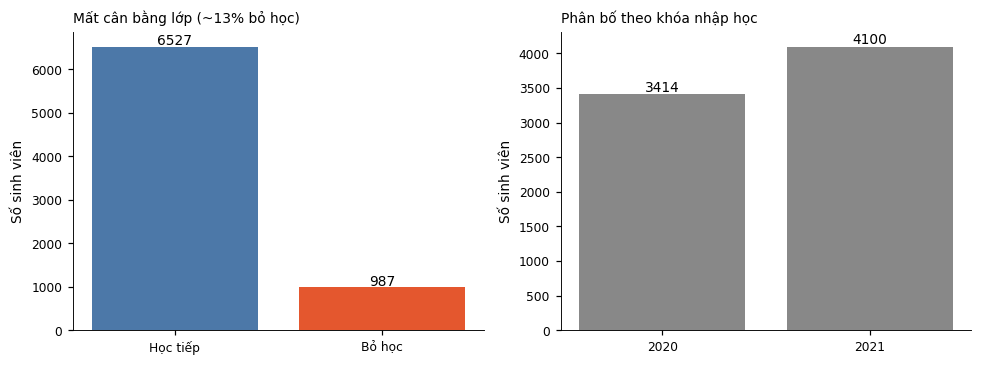

In [3]:
y = dr.get_target(df)
n = len(y); pos = int(y.sum()); rate = pos/n
print(f'Tổng: {n} sinh viên | Bỏ học: {pos} ({rate:.1%}) | Học tiếp: {n-pos} ({1-rate:.1%})')
print(f'Mất cân bằng ~ 1 : {(n-pos)/pos:.1f}')
print(f'scale_pos_weight (bù mất cân bằng cho LightGBM) = {dr.scale_pos_weight(y):.2f}')

ycol = [c for c in df.columns if 'Enroll' in c or 'Year' in c]
year = df[ycol[0]] if ycol else None

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].bar(['Học tiếp','Bỏ học'], [n-pos, pos], color=['#4C78A8','#E4572E'])
ax[0].set_title('Mất cân bằng lớp (~13% bỏ học)'); ax[0].set_ylabel('Số sinh viên')
for i,v in enumerate([n-pos,pos]): ax[0].text(i, v+40, str(v), ha='center', fontsize=9)
if year is not None:
    vc = year.value_counts().sort_index()
    ax[1].bar([str(int(k)) for k in vc.index], vc.values, color=META_GREY)
    ax[1].set_title('Phân bố theo khóa nhập học'); ax[1].set_ylabel('Số sinh viên')
    for i,v in enumerate(vc.values): ax[1].text(i, v+40, str(v), ha='center', fontsize=9)
fig.tight_layout()


## Bước 3 — Làm sạch và câu chuyện của "học kỳ trống"

Dữ liệu học kỳ có một đặc điểm quan trọng: **một sinh viên đã nghỉ/bỏ học sẽ có GPA = 0 ở các học kỳ sau**
(không còn đăng ký, không còn điểm). Đây *không phải lỗi nhập liệu* mà là **tín hiệu**: số sinh viên có
GPA = 0 **tăng dần** qua HK1→HK4 — đúng hình ảnh "rơi rụng theo thời gian".

Ngoài ra một phần nhỏ đặc trưng phái sinh (nguyện vọng, GPA trung bình…) có giá trị thiếu thật sự (`NaN`, ~1–2%).
Cách xử lý đúng:
1. **LightGBM giữ nguyên `NaN`** — thuật toán tự học hướng đi cho giá trị thiếu (native missing handling),
   nên không cần điền và không rò rỉ.
2. Mô hình truyền thống (Hồi quy logistic, Random Forest) cần điền → ta **điền trong từng fold**
   (in-fold imputation) để tập kiểm tra không "rò" thông tin sang tập huấn luyện.


Số sinh viên có GPA = 0 (đã nghỉ/không đăng ký) theo học kỳ:
  Học kỳ 1:  147 sinh viên (2.0%)
  Học kỳ 2:  480 sinh viên (6.4%)
  Học kỳ 3:  740 sinh viên (9.8%)
  Học kỳ 4:  812 sinh viên (10.8%)

Giá trị thiếu thật (NaN) trong đặc trưng — LightGBM tự xử lý:
  CreditRate_4          9.3%
  CreditsEarnned_4      9.3%
  RatingNum_4           9.3%
  GPA4_4                9.3%
  GPA4_3                7.8%
  CreditRate_3          7.8%


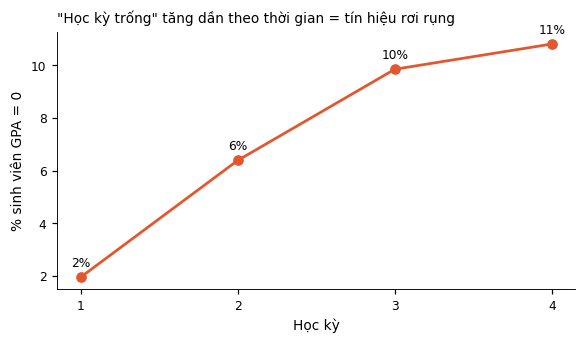

In [4]:
# 'Học kỳ trống' = GPA 0: đếm số sinh viên GPA==0 theo từng học kỳ
zero_gpa = [(df[f'GPA4_{k}']==0).sum() for k in range(1,5)]
print('Số sinh viên có GPA = 0 (đã nghỉ/không đăng ký) theo học kỳ:')
for k,z in zip(range(1,5), zero_gpa):
    print(f'  Học kỳ {k}: {z:4d} sinh viên ({z/len(df):.1%})')

# NaN thật trong ma trận đặc trưng (LightGBM xử lý native)
X4 = dr.build_features_raw(df, 4)
nan_share = X4.isna().mean().sort_values(ascending=False)
print('\nGiá trị thiếu thật (NaN) trong đặc trưng — LightGBM tự xử lý:')
for c,v in nan_share[nan_share>0].head(6).items():
    print(f'  {c:20s} {v:5.1%}')

fig, ax = plt.subplots(figsize=(5.4,3.2))
ax.plot(range(1,5), [z/len(df)*100 for z in zero_gpa], 'o-', color='#E4572E', lw=1.8)
ax.set_xticks(range(1,5)); ax.set_xlabel('Học kỳ'); ax.set_ylabel('% sinh viên GPA = 0')
ax.set_title('"Học kỳ trống" tăng dần theo thời gian = tín hiệu rơi rụng')
for k,z in zip(range(1,5), zero_gpa):
    ax.text(k, z/len(df)*100+0.4, f'{z/len(df):.0%}', ha='center', fontsize=8)
fig.tight_layout()


## Bước 4 — Khám phá: điều gì phân biệt sinh viên bỏ học?

Trước khi mô hình hóa, hãy để dữ liệu tự kể. Ta so sánh phân bố **GPA học kỳ 1** và **tỷ lệ cảnh báo học vụ**
giữa hai nhóm (bỏ học vs học tiếp). Nếu hai phân bố tách nhau rõ, bài toán *có tín hiệu để học* —
và ta cũng đoán trước được đâu sẽ là biến quan trọng ở Bước 12 (SHAP).


Nhóm bỏ học có GPA HK1 trung vị = 1.39 vs học tiếp = 2.53


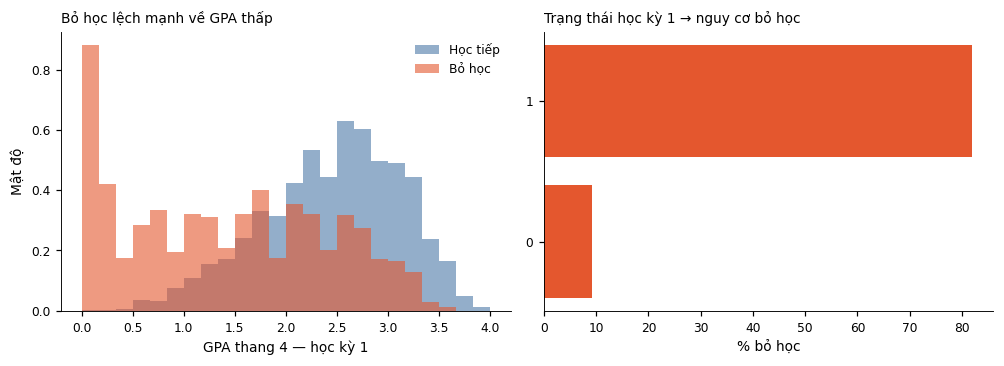

In [5]:
gpa1 = df['GPA4_1']; drop_mask = y.astype(bool)
fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.4))
# GPA HK1 theo nhóm
bins = np.linspace(0, 4, 25)
ax[0].hist(gpa1[~drop_mask].dropna(), bins=bins, density=True, alpha=0.6, label='Học tiếp', color='#4C78A8')
ax[0].hist(gpa1[drop_mask].dropna(),  bins=bins, density=True, alpha=0.6, label='Bỏ học', color='#E4572E')
ax[0].set_xlabel('GPA thang 4 — học kỳ 1'); ax[0].set_ylabel('Mật độ'); ax[0].legend()
ax[0].set_title('Bỏ học lệch mạnh về GPA thấp')
# Tỷ lệ bỏ học theo mức cảnh báo/ trạng thái HK1
ts = df['TermStatus_1'].astype(str)
rate_by = df.assign(_y=y).groupby(ts)['_y'].agg(['mean','size'])
rate_by = rate_by[rate_by['size']>=30].sort_values('mean', ascending=False).head(8)
ax[1].barh([str(i) for i in rate_by.index][::-1], (rate_by['mean']*100).values[::-1], color='#E4572E')
ax[1].set_xlabel('% bỏ học'); ax[1].set_title('Trạng thái học kỳ 1 → nguy cơ bỏ học')
fig.tight_layout()
print('Nhóm bỏ học có GPA HK1 trung vị =', round(float(gpa1[drop_mask].median()),2),
      'vs học tiếp =', round(float(gpa1[~drop_mask].median()),2))


## Bước 5 — Đặc trưng theo *tầm nhìn thời gian* và bằng chứng rò rỉ nhãn

Đây là quyết định thiết kế then chốt. Ta xây đặc trưng theo **horizon** = số học kỳ được "nhìn":

| Tầm nhìn | Horizon | Ý nghĩa thực tế | Vai trò |
|---|---|---|---|
| **HK1** | 1 | Chỉ dùng dữ liệu học kỳ 1 | Cảnh báo sớm — *phải kiểm chứng rò rỉ (Bước 5b)* |
| **HK1-2** | 2 | Dùng học kỳ 1+2 | Triển khai — *phải kiểm chứng rò rỉ (Bước 5b)* |
| **Đầy đủ** | 4 | Dùng cả 4 học kỳ | Tham chiếu — **rò rỉ hiển nhiên** |

**Tại sao "Đầy đủ" bị rò rỉ?** Trạng thái học kỳ 3–4 gần như *chính là* kết quả bỏ học (một sinh viên đã bỏ
thì HK4 trống/nghỉ). Dùng nó để dự báo là "nhìn trộm đáp án" → AUC ≈ 1.0 nhưng **vô giá trị** khi triển khai.

Nhưng lập luận **không được dừng ở đó**. Cùng cơ chế — *sinh viên đã rời trường để lại dấu vết
(GPA = 0, không đăng ký tín chỉ) ở các học kỳ sau* — tồn tại ngay trong dữ liệu HK2, và một phần trong HK1.
Ô dưới đo AUC theo **định nghĩa cũ** (toàn khóa, chưa lọc quần thể) làm mốc; **Bước 5b** truy vết,
chứng minh và loại bỏ phần rò rỉ còn lại.


In [6]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score

def quick_auc(horizon):
    """AUC 5-fold theo ĐỊNH NGHĨA CŨ: toàn bộ khóa, chưa lọc quần thể."""
    X = dr.build_features_raw(df, horizon)   # NaN + categorical: LightGBM xử lý native
    yy = dr.get_target(df)
    m = dr.make_lgbm(X, yy)
    cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
    p = cross_val_predict(m, X, yy, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
    return roc_auc_score(yy, p), X.shape[1]

print('AUC theo tầm nhìn — ĐỊNH NGHĨA CŨ (toàn khóa, chưa lọc quần thể):')
print(f'{"Tầm nhìn":26s}{"#đặc trưng":>11s}{"AUC":>8s}')
auc_old = {}
for name, h in dr.SCOPES.items():
    auc, nf = quick_auc(h)
    auc_old[name] = auc
    flag = '  <-- rò rỉ hiển nhiên' if auc > 0.99 else ''
    print(f'{name:26s}{nf:>11d}{auc:>8.3f}{flag}')
print()
print('Khung "Đầy đủ" AUC ~1.0: rò rỉ hiển nhiên (trạng thái HK3-4 gần như là nhãn).')
print('NHƯNG chưa được vội tin HK1-2: Bước 5b chứng minh nó cũng nhiễm cùng cơ chế,')
print('chỉ ở mức nhẹ hơn — và trình bày cách sửa tận gốc.')

AUC theo tầm nhìn — ĐỊNH NGHĨA CŨ (toàn khóa, chưa lọc quần thể):
Tầm nhìn                   #đặc trưng     AUC
HK1                                25   0.856
HK1-2                              36   0.955
Đầy đủ (4HK, tham chiếu)           48   1.000  <-- rò rỉ hiển nhiên

Khung "Đầy đủ" AUC ~1.0: rò rỉ hiển nhiên (trạng thái HK3-4 gần như là nhãn).
NHƯNG chưa được vội tin HK1-2: Bước 5b chứng minh nó cũng nhiễm cùng cơ chế,
chỉ ở mức nhẹ hơn — và trình bày cách sửa tận gốc.


### Bước 5b — HK1-2 cũng rò rỉ: truy vết bằng số liệu và sửa tận gốc

Nghi vấn bắt đầu từ một câu hỏi kiểm tra đơn giản: *nếu bỏ hết 36 đặc trưng đi, một cột thô duy nhất
làm được đến đâu?* Nguyên tắc chẩn đoán: **khi một cột đơn lẻ đạt AUC ngang cả mô hình, cột đó nhiều khả
năng là proxy của nhãn** — mô hình không "thông minh", nó chỉ chép lại đáp án nằm sẵn trong dữ liệu.

Ta đi ba bước như một cuộc điều tra: **(1)** đo sức mạnh của một cột đơn lẻ so với cả mô hình;
**(2)** "khám nghiệm" nhóm sinh viên tạo ra sức mạnh bất thường đó để xác định họ là *người học kém*
(tín hiệu thật) hay *người đã rời trường* (hệ quả của nhãn); **(3)** định nghĩa lại quần thể theo đúng
thời điểm dự báo và đo lại.


In [7]:
# BẰNG CHỨNG 1 — Một cột thô GPA4_2 "giỏi" ngang cả mô hình 36 đặc trưng
from sklearn.metrics import roc_auc_score
d = dr.clean_raw(df)                 # bản đã ép kiểu số
y_all = dr.get_target(df)

auc_1col = roc_auc_score(y_all, -d['GPA4_2'])     # GPA thấp = xếp hạng nguy cơ cao
print(f'AUC của MỘT MÌNH cột GPA4_2 (thô, toàn khóa): {auc_1col:.3f}')
print(f'AUC của cả mô hình LightGBM HK1-2 (ô trên)  : {auc_old["HK1-2"]:.3f}')
print()
print('Một cột ngang cả mô hình => GPA4_2 là proxy của nhãn. Vì sao? Nhìn phân bố GPA4_2 = 0:')
for lab, m in [('Bỏ học', y_all == 1), ('Học tiếp', y_all == 0)]:
    print(f'  {lab:9s}: GPA4_2==0 chiếm {(d.loc[m, "GPA4_2"] == 0).mean():6.1%}'
          f'   | không đăng ký tín chỉ HK2: {(d.loc[m, "CreditsRegistered_2"] == 0).mean():6.1%}')
print()
print('GPA HK2 = 0 gần như chỉ xuất hiện ở nhóm bỏ học — đó không phải "học kém",')
print('đó là DẤU VẾT của người đã rời trường. Mô hình 0.95 đang "phát hiện người')
print('đã đi", không phải dự báo tương lai. Nhưng khoan — biết đâu họ là người học')
print('mà trượt hết? Bằng chứng 2 phân xử.')

AUC của MỘT MÌNH cột GPA4_2 (thô, toàn khóa): 0.956
AUC của cả mô hình LightGBM HK1-2 (ô trên)  : 0.955

Một cột ngang cả mô hình => GPA4_2 là proxy của nhãn. Vì sao? Nhìn phân bố GPA4_2 = 0:
  Bỏ học   : GPA4_2==0 chiếm  47.4%   | không đăng ký tín chỉ HK2:  18.8%
  Học tiếp : GPA4_2==0 chiếm   0.2%   | không đăng ký tín chỉ HK2:   0.0%

GPA HK2 = 0 gần như chỉ xuất hiện ở nhóm bỏ học — đó không phải "học kém",
đó là DẤU VẾT của người đã rời trường. Mô hình 0.95 đang "phát hiện người
đã đi", không phải dự báo tương lai. Nhưng khoan — biết đâu họ là người học
mà trượt hết? Bằng chứng 2 phân xử.


In [8]:
# BẰNG CHỨNG 2 — Khám nghiệm nhóm nghi vấn: ĐĂNG KÝ học kỳ 2 nhưng GPA = 0.
# Hai giả thuyết cạnh tranh:
#   (a) Họ HỌC nhưng TRƯỢT HẾT      -> tín hiệu dự báo thật, phải giữ trong dữ liệu
#   (b) Họ ĐÃ BỎ ĐI giữa kỳ          -> hệ quả của nhãn (rò rỉ), phải loại khỏi quần thể
# Phân xử bằng 2 con số: tỷ lệ bỏ học của nhóm, và tỷ lệ "không đạt nổi MỘT tín chỉ".
g_noreg = d['CreditsRegistered_2'] == 0                          # không đăng ký gì
g_mid   = (d['CreditsRegistered_2'] > 0) & (d['GPA4_2'] == 0)    # NHÓM NGHI VẤN
g_ok    = (d['CreditsRegistered_2'] > 0) & (d['GPA4_2'] > 0)     # còn học thật sự

print(f'{"Nhóm (theo dữ liệu HK2)":34s}{"n":>6s}{"tỷ lệ bỏ học":>14s}{"0 tín chỉ đạt":>15s}')
for name, g in [('Không đăng ký tín chỉ', g_noreg),
                ('Đăng ký nhưng GPA = 0  << nghi vấn', g_mid),
                ('Đăng ký và có điểm', g_ok)]:
    earned0 = (d.loc[g, 'CreditsEarnned_2'] == 0).mean()
    print(f'{name:34s}{int(g.sum()):>6d}{y_all[g].mean():>14.1%}{earned0:>15.1%}')
print()
print('Phán quyết: nhóm nghi vấn bỏ học ~96%, và 100% không đạt nổi một tín chỉ.')
print('Người "học mà trượt hết" hiếm khi trượt SẠCH mọi môn đã đăng ký và rồi 96%')
print('rời trường — đây là hồ sơ của người bỏ đi giữa kỳ: giả thuyết (b) thắng.')
print()
print('=> Quần thể hợp lệ tại cuối HK2: CÓ ĐĂNG KÝ và CÓ ĐIỂM (định nghĩa "strict"')
print('   trong dropout_research.semester_active). Nhóm lỏng hơn (chỉ cần đăng ký)')
print('   giữ lại làm phân tích độ nhạy — xem docstring của hàm.')

Nhóm (theo dữ liệu HK2)                n  tỷ lệ bỏ học  0 tín chỉ đạt
Không đăng ký tín chỉ                187         99.5%         100.0%
Đăng ký nhưng GPA = 0  << nghi vấn   293         96.2%         100.0%
Đăng ký và có điểm                  7034          7.4%           0.0%

Phán quyết: nhóm nghi vấn bỏ học ~96%, và 100% không đạt nổi một tín chỉ.
Người "học mà trượt hết" hiếm khi trượt SẠCH mọi môn đã đăng ký và rồi 96%
rời trường — đây là hồ sơ của người bỏ đi giữa kỳ: giả thuyết (b) thắng.

=> Quần thể hợp lệ tại cuối HK2: CÓ ĐĂNG KÝ và CÓ ĐIỂM (định nghĩa "strict"
   trong dropout_research.semester_active). Nhóm lỏng hơn (chỉ cần đăng ký)
   giữ lại làm phân tích độ nhạy — xem docstring của hàm.


Hai bằng chứng trên buộc ta định nghĩa lại bài toán cho khớp thực tế triển khai. Tại cuối học kỳ h,
hệ cảnh báo chỉ đối mặt những sinh viên **còn đang học** — người đã rời trường là ca *đã biết*, không cần
mô hình. Vì vậy `dropout_research.horizon_dataset(df, h)` làm hai việc: **lọc quần thể** (chỉ giữ sinh viên
còn hoạt động ở học kỳ h — có đăng ký *và* có điểm) và nhờ đó **đổi nghĩa nhãn** thành *"bỏ học SAU cuối
học kỳ h"*. Cái giá phải trả — và phải trả một cách trung thực: tỷ lệ bỏ học trong quần thể mới thấp hơn
nhiều (bài toán khó hơn), nên mọi con số sẽ giảm. Đó không phải mô hình yếu đi, mà là **thước đo được chỉnh
về đúng câu hỏi**.

In [9]:
# BẰNG CHỨNG 3 — Đo lại trên quần thể đúng, so thẳng với định nghĩa cũ
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score)
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

print(f'{"Tầm nhìn":9s}{"Định nghĩa":17s}{"n":>7s}{"tỷ lệ bỏ học":>14s}{"AUC":>8s}{"PR-AUC":>9s}')
probs = {}
for name, h in [('HK1', 1), ('HK1-2', 2)]:
    X, yh, _ = dr.horizon_dataset(df, h)      # cohort strict — mặc định v2
    yh = np.asarray(yh)
    p = cross_val_predict(dr.make_lgbm(X), X, yh, cv=cv,
                          method='predict_proba', n_jobs=1)[:, 1]
    probs[name] = (yh, p)
    print(f'{name:9s}{"CŨ (toàn khóa)":17s}{len(df):>7d}{y_all.mean():>14.1%}{auc_old[name]:>8.3f}{"—":>9s}')
    print(f'{name:9s}{"MỚI (cohort)":17s}{len(yh):>7d}{yh.mean():>14.1%}'
          f'{roc_auc_score(yh, p):>8.3f}{average_precision_score(yh, p):>9.3f}')
print()
# Hệ quả trực tiếp lên "hệ thống cảnh báo hai tầng" (Bước 13):
yh, p = probs['HK1-2']
print('Áp ngưỡng cảnh báo cũ lên quần thể đúng (HK1-2, chưa hiệu chỉnh xác suất):')
for thr in (0.20, 0.40):
    pred = (p >= thr).astype(int)
    print(f'  p >= {thr:.2f}: recall={recall_score(yh, pred):.3f}'
          f'  precision={precision_score(yh, pred):.3f}  gắn cờ={pred.mean():.1%}')
print()
print('Đọc kết quả: AUC HK1-2 rơi ~0.95 -> ~0.92, và precision "Tầng 2" không còn')
print('~0.89 — vì các con số cũ được chấm trên đề thi dễ hơn (lẫn người đã rời')
print('trường). Con số mới thấp hơn nhưng đo đúng bài toán triển khai.')

Tầm nhìn Định nghĩa             n  tỷ lệ bỏ học     AUC   PR-AUC
HK1      CŨ (toàn khóa)      7514         13.1%   0.856        —
HK1      MỚI (cohort)        7367         11.5%   0.839    0.527
HK1-2    CŨ (toàn khóa)      7514         13.1%   0.955        —
HK1-2    MỚI (cohort)        7034          7.4%   0.915    0.691

Áp ngưỡng cảnh báo cũ lên quần thể đúng (HK1-2, chưa hiệu chỉnh xác suất):
  p >= 0.20: recall=0.680  precision=0.508  gắn cờ=9.9%
  p >= 0.40: recall=0.638  precision=0.625  gắn cờ=7.5%

Đọc kết quả: AUC HK1-2 rơi ~0.95 -> ~0.92, và precision "Tầng 2" không còn
~0.89 — vì các con số cũ được chấm trên đề thi dễ hơn (lẫn người đã rời
trường). Con số mới thấp hơn nhưng đo đúng bài toán triển khai.


**Hệ quả cho phần còn lại của notebook.** Từ Bước 6 trở đi, mọi kết quả (so sánh mô hình, nested CV,
hiệu chỉnh xác suất, kiểm định thời gian, công bằng nhóm, SHAP, ngưỡng hai tầng) phải được tính trên
`horizon_dataset()` — các bảng và hình đang nạp từ checkpoint là sản phẩm của **định nghĩa cũ** và cần
chạy lại (`RECOMPUTE=True`) trước khi đưa vào luận văn. Riêng phân tích SHAP cần đọc lại một cách thận
trọng: vị trí số 1 của `GPA4_2` trong bản cũ một phần là lập luận vòng (GPA = 0 *vì* đã bỏ học).
Một điểm treo cần xác nhận với phòng đào tạo: ngữ nghĩa `TermStatus` (cảnh báo học vụ *hay* đã nghỉ học) —
kết quả mới gần như không đổi khi bỏ hẳn biến này (AUC ~0.914 so với ~0.915), nên kết luận không phụ thuộc
vào nó, nhưng luận văn phải ghi rõ giả định.

## Bước 6 — Pipeline sạch: điền giá trị thiếu *trong từng fold*

Một lỗi kinh điển làm kết quả bị thổi phồng: điền giá trị thiếu / chuẩn hóa **trên toàn bộ dữ liệu**
rồi mới chia train/test. Khi đó thống kê của tập test đã "rò" vào bước tiền xử lý.

Khung `dropout_research.py` tránh lỗi này:
- **LightGBM**: không điền gì — giữ `NaN`, xử lý native.
- **Hồi quy logistic / Random Forest**: gói trong `Pipeline(SimpleImputer → [StandardScaler] → model)`,
  và `imputer/scaler` chỉ `fit` trên **tập huấn luyện của mỗi fold**. Đây là ý nghĩa của "in-fold imputation".

Nhờ vậy mọi con số AUC/Recall ở các bước sau đều là **ước lượng trung thực** cho dữ liệu mới.


In [10]:
from sklearn.pipeline import Pipeline
# Minh họa: cấu trúc pipeline của baseline (không fit — chỉ xem để hiểu)
logreg = dr.make_sklearn_baseline('logreg', dr.build_features_raw(df,2), y)
rf     = dr.make_sklearn_baseline('rf',     dr.build_features_raw(df,2), y)
def describe(pipe, name):
    if isinstance(pipe, Pipeline):
        steps = ' → '.join(t.__class__.__name__ for _,t in pipe.steps)
    else:
        steps = pipe.__class__.__name__
    print(f'{name:22s}: {steps}')
describe(logreg, 'Hồi quy logistic')
describe(rf,     'Random Forest')
describe(dr.make_lgbm(dr.build_features_raw(df,2), y), 'LightGBM')
print('\nMọi bước điền/chuẩn hóa nằm TRONG pipeline → chỉ fit trên train của mỗi fold (in-fold).')


Hồi quy logistic      : ColumnTransformer → LogisticRegression
Random Forest         : ColumnTransformer → RandomForestClassifier
LightGBM              : LGBMClassifier

Mọi bước điền/chuẩn hóa nằm TRONG pipeline → chỉ fit trên train của mỗi fold (in-fold).


## Bước 7 — Huấn luyện & so sánh 3 thuật toán cơ sở (kèm khoảng tin cậy)

Giờ là phần cốt lõi: so sánh **Hồi quy logistic**, **Random Forest** và **LightGBM** trên hai tầm nhìn
HK1 và HK1-2. Cả ba đều dùng **tham số mặc định** dưới cùng một giao thức — mục này trả lời câu hỏi
*thuật toán nào phù hợp với dữ liệu này*, tách khỏi câu hỏi *tối ưu siêu tham số giúp được bao nhiêu*.

> **Vì sao không đưa "LightGBM tinh chỉnh" vào bảng này?** Việc tinh chỉnh siêu tham số của LightGBM được
> đánh giá **riêng** bằng nested cross-validation (Bước 9), để tránh trộn lẫn ảnh hưởng của thuật toán với
> ảnh hưởng của tối ưu hóa siêu tham số. Nếu chỉ tinh chỉnh riêng LightGBM rồi so với các mô hình chưa
> tinh chỉnh, phép so sánh sẽ không còn công bằng — và sẽ khó trả lời câu hỏi "vì sao không tinh chỉnh cả
> Random Forest và hồi quy logistic?".

Mỗi chỉ số đi kèm **khoảng tin cậy 95%** (bootstrap) và **độ lệch giữa các lần lặp CV** — để biết con số
*chắc chắn tới đâu*, không chỉ là một điểm số trần trụi. Bảng `metrics_with_ci.csv` được nạp từ
`05_KetQua_ThongKe/`.

In [11]:
mci = load_tab('metrics_with_ci.csv')
# Bảng AUC theo mô hình cho HK1-2
def show(scope, metric='AUC'):
    t = mci[(mci.scope==scope)&(mci.metric==metric)][['model','point','ci_lo','ci_hi','repeat_std']]
    t = t.copy()
    t['AUC (KTC 95%)'] = t.apply(lambda r: f"{r.point:.3f} [{r.ci_lo:.3f}–{r.ci_hi:.3f}]", axis=1)
    return t[['model','AUC (KTC 95%)','repeat_std']].reset_index(drop=True)
print('=== HK1-2 (triển khai) — AUC ===')
print(show('HK1-2').to_string(index=False))
print('\n=== HK1 (cảnh báo sớm) — AUC ===')
print(show('HK1').to_string(index=False))
__disp__ = show('HK1-2')


=== HK1-2 (triển khai) — AUC ===
              model       AUC (KTC 95%)  repeat_std
Logistic Regression 0.928 [0.915–0.940]    0.001472
      Random Forest 0.921 [0.908–0.934]    0.001570
LightGBM (mặc định) 0.920 [0.907–0.933]    0.002928

=== HK1 (cảnh báo sớm) — AUC ===
              model       AUC (KTC 95%)  repeat_std
Logistic Regression 0.846 [0.832–0.861]    0.001564
      Random Forest 0.835 [0.821–0.850]    0.002258
LightGBM (mặc định) 0.844 [0.829–0.857]    0.003193


Hình dưới (`fig_metric_ci.png`) trực quan hóa AUC ± khoảng tin cậy cho từng mô hình và tầm nhìn:

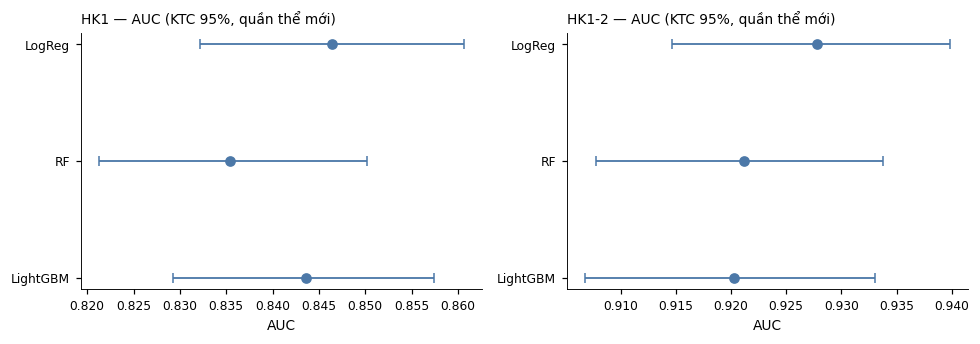

In [12]:
# Hình: AUC kèm khoảng tin cậy 95% cho từng thuật toán và tầm nhìn
import os
os.makedirs(FIGS, exist_ok=True)
mci = load_tab('metrics_with_ci.csv')
t = mci[mci.metric == 'AUC']
short = {'Logistic Regression': 'LogReg', 'Random Forest': 'RF',
         'LightGBM (mặc định)': 'LightGBM'}
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, scope in zip(axes, ['HK1', 'HK1-2']):
    s = t[t.scope == scope].reset_index(drop=True)
    ypos = np.arange(len(s))[::-1]
    ax.errorbar(s['point'], ypos, xerr=[s['point']-s['ci_lo'], s['ci_hi']-s['point']],
                fmt='o', color='#4C78A8', capsize=3, lw=1.2)
    ax.set_yticks(ypos); ax.set_yticklabels([short[m] for m in s['model']])
    ax.set_title(f'{scope} — AUC (KTC 95%, quần thể mới)'); ax.set_xlabel('AUC')
fig.tight_layout(); fig.savefig(os.path.join(FIGS, 'fig_metric_ci.png'))

## Bước 8 — Kiểm định: LightGBM có *thật sự* thắng không?

Luận văn gốc kết luận "LightGBM thắng rõ". Nhưng khoa học đòi hỏi **kiểm định thống kê**, không thể nhìn
chênh lệch vài phần nghìn AUC rồi tuyên bố người thắng. Ta dùng **kiểm định DeLong** (so sánh hai AUC trên
cùng dữ liệu) kèm **hiệu chỉnh Holm** cho đa so sánh — tất cả trên quần thể đã loại rò rỉ (Bước 5b).

**Kết quả trung thực:** ở cả HK1 và HK1-2, **không mô hình nào vượt trội có ý nghĩa thống kê** — mọi
`p_holm > 0,05` và |ΔAUC| ≤ 0,011. Ba họ mô hình *tương đương về phân biệt*; ta chọn LightGBM không phải vì
AUC mà vì **Brier tốt nhất ở cả hai tầm nhìn** (0,090 ở HK1; 0,039 ở HK1-2 — xác suất đáng tin hơn hẳn
hồi quy logistic 0,150/0,087), **PR-AUC cao nhất ở HK1** (0,537), xử lý NaN/biến phân loại native,
và **giải thích được bằng SHAP**.


In [13]:
sig = load_tab('model_significance.csv')
cols = ['scope','model_A','model_B','dAUC','delong_p','delong_p_holm']
t = sig[cols].copy()
t['dAUC'] = t['dAUC'].round(4)
t['delong_p'] = t['delong_p'].round(3)
t['delong_p_holm'] = t['delong_p_holm'].round(3)
t['Kết luận'] = np.where(t['delong_p_holm']>0.05, 'Không khác biệt', 'Khác biệt')
print(t.to_string(index=False))
print('\n=> Mọi p_holm > 0.05: các mô hình TƯƠNG ĐƯƠNG. Chọn LightGBM vì Brier + giải thích được.')
__disp__ = t


scope             model_A             model_B    dAUC  delong_p  delong_p_holm        Kết luận
  HK1 Logistic Regression       Random Forest  0.0110     0.017          0.050       Khác biệt
  HK1 Logistic Regression LightGBM (mặc định)  0.0028     0.495          0.495 Không khác biệt
  HK1       Random Forest LightGBM (mặc định) -0.0083     0.042          0.084 Không khác biệt
HK1-2 Logistic Regression       Random Forest  0.0066     0.065          0.131 Không khác biệt
HK1-2 Logistic Regression LightGBM (mặc định)  0.0074     0.029          0.088 Không khác biệt
HK1-2       Random Forest LightGBM (mặc định)  0.0009     0.794          0.794 Không khác biệt

=> Mọi p_holm > 0.05: các mô hình TƯƠNG ĐƯƠNG. Chọn LightGBM vì Brier + giải thích được.


Hình `fig_model_comparison.png` — AUC các mô hình chồng lấn khoảng tin cậy (không ai thắng rõ):

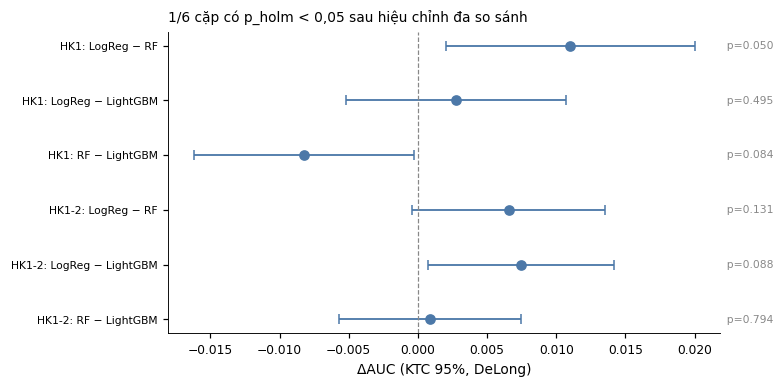

In [14]:
# Hình: chênh lệch AUC từng cặp thuật toán (DeLong + hiệu chỉnh Holm)
import os
sig = load_tab('model_significance.csv')
short = {'Logistic Regression': 'LogReg', 'Random Forest': 'RF',
         'LightGBM (mặc định)': 'LightGBM'}
s = sig[sig.model_A != sig.model_B].copy()
lab = [f"{r.scope}: {short[r.model_A]} − {short[r.model_B]}" for r in s.itertuples()]
ci = np.where(s['delong_z'] != 0, 1.96*np.abs(s['dAUC']/s['delong_z'].replace(0, np.nan)), 0)
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ypos = np.arange(len(s))[::-1]
ax.errorbar(s['dAUC'], ypos, xerr=ci, fmt='o', color='#4C78A8', capsize=3, lw=1.2)
ax.axvline(0, color='#888888', lw=0.8, ls='--')
for yy, p in zip(ypos, s['delong_p_holm']):
    ax.text(ax.get_xlim()[1], yy, f'  p={p:.3f}', va='center', fontsize=7, color='#888888')
ax.set_yticks(ypos); ax.set_yticklabels(lab, fontsize=7)
n_sig = int((s['delong_p_holm'] < 0.05).sum())
ax.set_xlabel('ΔAUC (KTC 95%, DeLong)')
ax.set_title(f'{n_sig}/{len(s)} cặp có p_holm < 0,05 sau hiệu chỉnh đa so sánh')
fig.tight_layout(); fig.savefig(os.path.join(FIGS, 'fig_model_comparison.png'))

## Bước 9 — Tinh chỉnh có làm mô hình "ảo" không? (Nested CV)

Khi ta dùng Optuna dò siêu tham số rồi báo cáo AUC trên *cùng* vòng CV đó, con số sẽ bị **lạc quan hóa**
(optimism bias) — mô hình được "chấm điểm trên chính đề thi nó luyện". Cách kiểm định vàng là **nested CV**:
vòng ngoài đánh giá, vòng trong (Optuna 40 lần thử) mới được tinh chỉnh — hai vòng tách biệt.

**Kết quả:** nested CV (HK1) cho **AUC = 0,8498 ± 0,0098**, và **optimism gap ≈ −0,005** (điểm inner còn
*thấp hơn* điểm outer một chút). Nghĩa là mô hình tinh chỉnh **không bị thổi phồng**, và trong tầm nhìn này
nó *ngang bằng* mô hình mặc định — một kết quả trung thực và đáng tin.


In [15]:
ncv = load_tab('nested_cv_results.csv')
mci = load_tab('metrics_with_ci.csv')
print(ncv.to_string(index=False))

nested_auc = ncv['test_AUC'].mean()
default_auc = mci[(mci.scope == 'HK1') & (mci.model == 'LightGBM (mặc định)')
                  & (mci.metric == 'AUC')]['point'].iloc[0]
improvement_after_nested_tuning = nested_auc - default_auc

print(f"\nLightGBM tinh chỉnh — nested CV (đánh giá không thiên lệch) = {nested_auc:.4f} ± {ncv['test_AUC'].std():.4f}")
print(f"LightGBM tham số mặc định — CV lặp lại (HK1)                = {default_auc:.4f}")
print(f"=> Cải thiện nhờ tinh chỉnh siêu tham số: ΔAUC = {improvement_after_nested_tuning:+.4f}")
print()
print("LƯU Ý PHƯƠNG PHÁP: đây KHÔNG phải ước lượng 'optimism' của quy trình tinh chỉnh.")
print("Đo optimism đòi hỏi so sánh tinh chỉnh PHẲNG với tinh chỉnh LỒNG NHAU;")
print("nghiên cứu này không thực hiện quy trình tinh chỉnh phẳng độc lập, nên không kết luận về optimism.")
__disp__ = ncv

 outer_fold  test_AUC  test_AP  inner_best_AUC
          0  0.849486 0.544687        0.841469
          1  0.851908 0.532618        0.847747
          2  0.860207 0.504096        0.844618
          3  0.833235 0.549735        0.848291
          4  0.858411 0.579406        0.839714

LightGBM tinh chỉnh — nested CV (đánh giá không thiên lệch) = 0.8506 ± 0.0107
LightGBM tham số mặc định — CV lặp lại (HK1)                = 0.8436
=> Cải thiện nhờ tinh chỉnh siêu tham số: ΔAUC = +0.0070

LƯU Ý PHƯƠNG PHÁP: đây KHÔNG phải ước lượng 'optimism' của quy trình tinh chỉnh.
Đo optimism đòi hỏi so sánh tinh chỉnh PHẲNG với tinh chỉnh LỒNG NHAU;
nghiên cứu này không thực hiện quy trình tinh chỉnh phẳng độc lập, nên không kết luận về optimism.


Hình `fig_nested_vs_flat.png` — so sánh AUC nested (trung thực) vs flat (lạc quan):

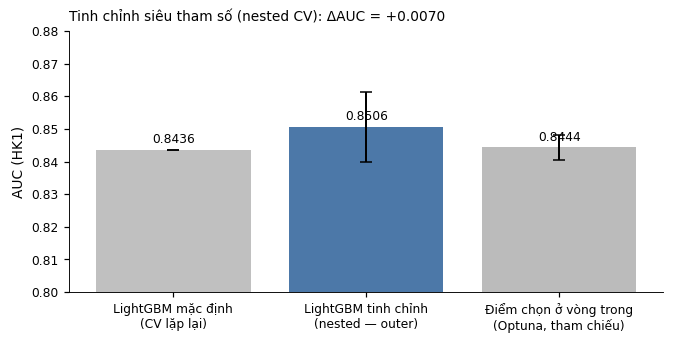

In [16]:
# Hình: LightGBM mặc định so với LightGBM tinh chỉnh bằng nested CV
import os
ncv = load_tab('nested_cv_results.csv')
mci = load_tab('metrics_with_ci.csv')
default_row = mci[(mci.scope == 'HK1') & (mci.model == 'LightGBM (mặc định)')
                  & (mci.metric == 'AUC')].iloc[0]
improvement_after_nested_tuning = ncv.test_AUC.mean() - default_row['point']

names = ['LightGBM mặc định\n(CV lặp lại)',
         'LightGBM tinh chỉnh\n(nested — outer)',
         'Điểm chọn ở vòng trong\n(Optuna, tham chiếu)']
vals = [default_row['point'], ncv.test_AUC.mean(), ncv.inner_best_AUC.mean()]
errs = [0, ncv.test_AUC.std(), ncv.inner_best_AUC.std()]
fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.bar(names, vals, yerr=errs, capsize=4, color=['#C0C0C0', '#4C78A8', '#BBBBBB'])
ax.set_ylim(0.80, 0.88); ax.set_ylabel('AUC (HK1)')
ax.set_title(f'Tinh chỉnh siêu tham số (nested CV): ΔAUC = {improvement_after_nested_tuning:+.4f}')
for i, v in enumerate(vals): ax.text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(FIGS, 'fig_nested_vs_flat.png'))

## Bước 10 — Xác suất có *đáng tin* không? Hiệu chỉnh & lợi ích quyết định

Một mô hình cảnh báo phải cho **xác suất đúng nghĩa**: nếu nói "nguy cơ 30%" thì trong 100 sinh viên như vậy,
đúng khoảng 30 em bỏ học. Đó là **hiệu chuẩn (calibration)**. Ta đo bằng **Brier score** và **ECE**, rồi
áp hiệu chỉnh **isotonic / sigmoid** (fit in-fold).

**Kết quả (HK1-2, LightGBM, quần thể mới):** chưa hiệu chỉnh Brier 0,0415 / ECE 0,0339 → sau **isotonic**
Brier 0,0363 / **ECE 0,0047**. Lưu ý cách diễn đạt: với n ≈ 7.000, ECE có "sàn nhiễu" ~0,005 ngay cả khi
hiệu chuẩn hoàn hảo — nên kết luận đúng là *không phát hiện miscalibration đáng kể*, không phải "hoàn hảo".
Ngoài ra **Decision Curve Analysis** cho thấy dùng mô hình để chọn sinh viên can thiệp có lợi ích ròng
cao hơn chiến lược "can thiệp tất cả" hay "không can thiệp ai" trong dải ngưỡng thực dụng.


In [17]:
cal = load_ckpt('calibration.pkl')
cs = cal['cal_stats']   # dict: phương pháp -> (Brier, ECE)
print('Hiệu chuẩn xác suất (HK1-2, LightGBM):')
print(f'{"Phương pháp":16s}{"Brier":>10s}{"ECE":>10s}')
labels = {'uncalibrated':'Chưa hiệu chỉnh','isotonic':'Isotonic','sigmoid':'Sigmoid'}
for k in ['uncalibrated','isotonic','sigmoid']:
    if k in cs:
        brier, ece = cs[k]
        print(f'{labels[k]:16s}{brier:>10.4f}{ece:>10.4f}')
print('=> Isotonic: ECE ~0.005 nằm trong sàn nhiễu (n~7k) — không phát hiện miscalibration đáng kể.')

dca = load_tab('decision_curve.csv')
row = dca.iloc[(dca['threshold']-0.15).abs().argmin()]
print(f"\nDecision Curve @ ngưỡng {row['threshold']:.2f}: lợi ích ròng MÔ HÌNH "
      f"{row['nb_model']:.3f}  vs  can-thiệp-tất-cả {row['nb_all']:.3f}  vs  không-ai {row['nb_none']:.3f}")


Hiệu chuẩn xác suất (HK1-2, LightGBM):
Phương pháp          Brier       ECE
Chưa hiệu chỉnh     0.0415    0.0339
Isotonic            0.0363    0.0047
Sigmoid             0.0374    0.0059
=> Isotonic: ECE ~0.005 nằm trong sàn nhiễu (n~7k) — không phát hiện miscalibration đáng kể.

Decision Curve @ ngưỡng 0.15: lợi ích ròng MÔ HÌNH 0.042  vs  can-thiệp-tất-cả -0.090  vs  không-ai 0.000


Hai hình chủ chốt — `fig_calibration.png` (đường hiệu chuẩn) và `fig_decision_curve.png` (lợi ích ròng):

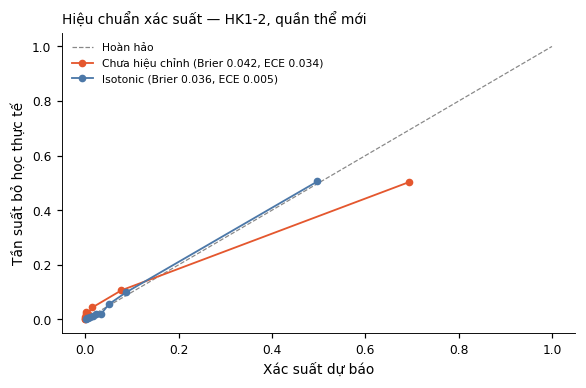

In [18]:
# Hình: đường hiệu chuẩn (reliability curve) trước và sau isotonic
import os
cal = load_ckpt('calibration.pkl')
yv = np.asarray(cal['y'])
fig, ax = plt.subplots(figsize=(5.4, 3.6))
ax.plot([0, 1], [0, 1], '--', color='#888888', lw=0.8, label='Hoàn hảo')
for key, lab, col in [('p_uncal', 'Chưa hiệu chỉnh', '#E4572E'), ('p_iso', 'Isotonic', '#4C78A8')]:
    p = np.asarray(cal[key])
    bins = np.quantile(p, np.linspace(0, 1, 11))
    bins[0], bins[-1] = 0, 1
    idx = np.clip(np.digitize(p, bins) - 1, 0, 9)
    mp = [p[idx == b].mean() for b in range(10) if (idx == b).sum() > 0]
    fr = [yv[idx == b].mean() for b in range(10) if (idx == b).sum() > 0]
    b_, e_ = cal['cal_stats']['uncalibrated' if key == 'p_uncal' else 'isotonic']
    ax.plot(mp, fr, 'o-', color=col, lw=1.2, ms=4, label=f'{lab} (Brier {b_:.3f}, ECE {e_:.3f})')
ax.set_xlabel('Xác suất dự báo'); ax.set_ylabel('Tần suất bỏ học thực tế')
ax.set_title('Hiệu chuẩn xác suất — HK1-2, quần thể mới'); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(os.path.join(FIGS, 'fig_calibration.png'))

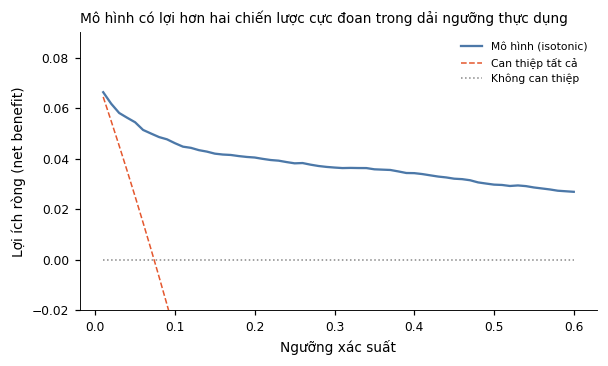

In [19]:
# Hình: Decision Curve Analysis — lợi ích ròng theo ngưỡng
import os
dca = load_tab('decision_curve.csv')
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(dca['threshold'], dca['nb_model'], color='#4C78A8', lw=1.5, label='Mô hình (isotonic)')
ax.plot(dca['threshold'], dca['nb_all'], color='#E4572E', lw=1.0, ls='--', label='Can thiệp tất cả')
ax.plot(dca['threshold'], dca['nb_none'], color='#888888', lw=1.0, ls=':', label='Không can thiệp')
ax.set_ylim(-0.02, max(dca['nb_model'].max(), 0.08) + 0.01)
ax.set_xlabel('Ngưỡng xác suất'); ax.set_ylabel('Lợi ích ròng (net benefit)')
ax.set_title('Mô hình có lợi hơn hai chiến lược cực đoan trong dải ngưỡng thực dụng')
ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(os.path.join(FIGS, 'fig_decision_curve.png'))

## Bước 11 — Bền theo thời gian & công bằng giữa các nhóm

Một mô hình chỉ hữu ích nếu nó **không sập khi gặp khóa mới** và **không thiên vị nhóm yếu thế**. Ta kiểm hai điều:

1. **Kiểm định thời gian** — huấn luyện khóa **2020** (n = 3.159), kiểm tra khóa **2021** (n = 3.875),
   trên quần thể đã loại rò rỉ. Đây là mô phỏng sát thực tế triển khai: dự báo tương lai bằng quá khứ.
2. **Công bằng nhóm** — so AUC giữa **giới tính** và **dân tộc** (Kinh / thiểu số), kèm khoảng tin cậy.

**Kết quả:** theo thời gian **AUC 0,884 [0,858–0,907]** — thấp hơn CV trộn khóa (0,92) như kỳ vọng, nhưng
vẫn ở mức dùng được. Về công bằng, các khoảng tin cậy AUC **chồng lấn** (Nữ 0,909, Nam 0,916, Kinh 0,920,
thiểu số 0,882 với KTC rộng do n = 555) → không có chênh lệch phân biệt có ý nghĩa thống kê. Một điểm cần
ghi vào hạn chế: ở ngưỡng chung 0,5, recall của nhóm Nữ (0,43) thấp hơn Nam (0,58) vì tỷ lệ bỏ học nền của
hai nhóm khác nhau (5,2% vs 12,6%) — khi triển khai nên cân nhắc chọn ngưỡng theo mục tiêu recall từng nhóm.


In [20]:
tci = load_tab('temporal_ci.csv')
print('=== Kiểm định thời gian (train 2020 → test 2021, n=3.875) ===')
for _,r in tci.iterrows():
    print(f"  {r['metric']:10s} {r['point']:.3f} [{r['lo']:.3f}–{r['hi']:.3f}]")

fci = load_tab('fairness_ci.csv')
print('\n=== Công bằng nhóm (HK1-2, OOF isotonic) ===')
show = fci[['attr','group','n','dropout_rate','AUC','AUC_lo','AUC_hi','Recall']].copy()
show['AUC (KTC)'] = show.apply(lambda r: f"{r.AUC:.3f} [{r.AUC_lo:.3f}–{r.AUC_hi:.3f}]", axis=1)
print(show[['attr','group','n','AUC (KTC)','Recall']].to_string(index=False))
print('\n=> Các KTC AUC chồng lấn: không chênh lệch có ý nghĩa giữa nhóm.')
__disp__ = show[['attr','group','n','AUC (KTC)','Recall']]


=== Kiểm định thời gian (train 2020 → test 2021, n=3.875) ===
  AUC        0.884 [0.858–0.907]
  AP         0.621 [nan–nan]
  Recall@0.5 0.514 [nan–nan]
  Precision@0.5 0.700 [nan–nan]

=== Công bằng nhóm (HK1-2, OOF isotonic) ===
     attr            group    n           AUC (KTC)   Recall
Giới tính               Nữ 4978 0.909 [0.887–0.929] 0.424710
Giới tính              Nam 2056 0.916 [0.895–0.935] 0.576923
  Dân tộc             Kinh 6479 0.920 [0.907–0.934] 0.501053
  Dân tộc Dân tộc thiểu số  555 0.882 [0.818–0.938] 0.500000

=> Các KTC AUC chồng lấn: không chênh lệch có ý nghĩa giữa nhóm.


Hình `fig_temporal_ci.png` và `fig_fairness_gap.png`:

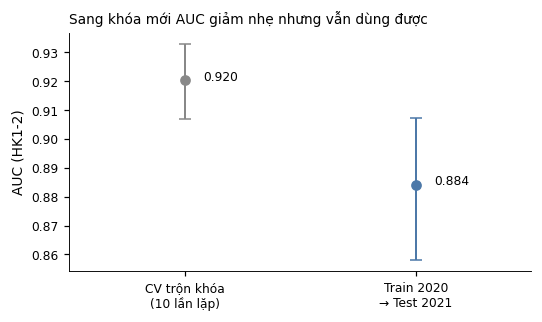

In [21]:
# Hình: AUC kiểm định thời gian so với CV trộn khóa
import os
tci = load_tab('temporal_ci.csv')
mci = load_tab('metrics_with_ci.csv')
cv2 = mci[(mci.scope == 'HK1-2') & (mci.model == 'LightGBM (mặc định)') & (mci.metric == 'AUC')].iloc[0]
tp = tci[tci.metric == 'AUC'].iloc[0]
fig, ax = plt.subplots(figsize=(5.0, 3.0))
ax.errorbar([0], [cv2['point']], yerr=[[cv2['point']-cv2['ci_lo']], [cv2['ci_hi']-cv2['point']]],
            fmt='o', color='#888888', capsize=4, label='CV trộn khóa')
ax.errorbar([1], [tp['point']], yerr=[[tp['point']-tp['lo']], [tp['hi']-tp['point']]],
            fmt='o', color='#4C78A8', capsize=4, label='2020 → 2021')
ax.set_xticks([0, 1]); ax.set_xticklabels(['CV trộn khóa\n(10 lần lặp)', 'Train 2020\n→ Test 2021'])
ax.set_ylabel('AUC (HK1-2)'); ax.set_xlim(-0.5, 1.5)
ax.set_title('Sang khóa mới AUC giảm nhẹ nhưng vẫn dùng được')
for x, v in [(0, cv2['point']), (1, tp['point'])]: ax.text(x+0.08, v, f'{v:.3f}', fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(FIGS, 'fig_temporal_ci.png'))

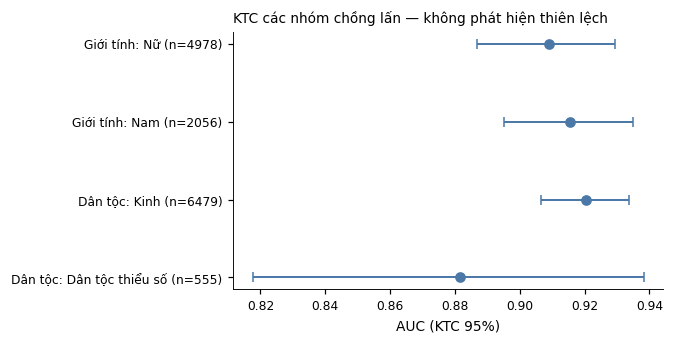

In [22]:
# Hình: công bằng nhóm — AUC kèm khoảng tin cậy chồng lấn
import os
fci = load_tab('fairness_ci.csv')
fig, ax = plt.subplots(figsize=(6.2, 3.2))
ypos = np.arange(len(fci))[::-1]
ax.errorbar(fci['AUC'], ypos, xerr=[fci['AUC']-fci['AUC_lo'], fci['AUC_hi']-fci['AUC']],
            fmt='o', color='#4C78A8', capsize=3)
ax.set_yticks(ypos)
ax.set_yticklabels([f"{r.attr}: {r.group} (n={r.n})" for r in fci.itertuples()], fontsize=8)
ax.set_xlabel('AUC (KTC 95%)'); ax.set_title('KTC các nhóm chồng lấn — không phát hiện thiên lệch')
fig.tight_layout(); fig.savefig(os.path.join(FIGS, 'fig_fairness_gap.png'))

## Bước 12 — Yếu tố nào *liên quan* đến bỏ học? Giải thích bằng SHAP

Dự báo đúng chưa đủ — luận văn phải **chỉ ra các yếu tố liên quan**. Ta dùng **SHAP** (giá trị Shapley) đo
mức đóng góp của từng đặc trưng vào dự báo, và kiểm **độ ổn định** qua 5 fold: một yếu tố đáng tin phải
xuất hiện ở *cả 5 fold*. Lưu ý phương pháp: SHAP đo mức *liên quan trong dự báo*, **không phải quan hệ
nhân quả** — mọi diễn giải dưới đây là "yếu tố ảnh hưởng đến dự báo".

**Các yếu tố hàng đầu (HK1-2, quần thể đã loại rò rỉ):**
1. **Ngành học** (IndustryCode, |SHAP| ≈ 1,10; 5/5 fold) — sau khi loại rò rỉ, ngành học vượt lên vị trí số 1:
   một số ngành có nguy cơ cao hơn hẳn.
2. **GPA học kỳ 2** (≈ 0,90; 5/5) — vẫn rất quan trọng, nhưng giờ là tín hiệu thật của sinh viên *còn đang học*,
   không còn là proxy của nhãn như bản cũ (bản cũ |SHAP| 1,19 một phần là lập luận vòng).
3. **Tỷ lệ tín chỉ đạt HK2** (CreditRate_2 ≈ 0,27) và **GPA thấp nhất** (GPA_min ≈ 0,25).
4. **Điểm đầu vào** (SumScore ≈ 0,25; 5/5) — nền tảng học lực trước đại học.

Đây là **cơ sở để thiết kế can thiệp** ở Bước 13: tư vấn theo ngành, hỗ trợ học tập sớm khi GPA/tín chỉ sụt.


In [23]:
ss = load_tab('shap_stability.csv').sort_values('mean_abs_shap', ascending=False)
top = ss.head(8)[['feature','mean_abs_shap','sd','top10_freq']].copy()
top.columns = ['Đặc trưng','|SHAP| TB','Độ lệch','Tần suất top-10 (×/5 fold)']
print('Top đặc trưng theo mức ảnh hưởng trung bình (|SHAP|), kèm độ ổn định:')
print(top.to_string(index=False))
__disp__ = top


Top đặc trưng theo mức ảnh hưởng trung bình (|SHAP|), kèm độ ổn định:
   Đặc trưng  |SHAP| TB  Độ lệch  Tần suất top-10 (×/5 fold)
IndustryCode   1.098496 0.065778                           5
      GPA4_2   0.897320 0.185413                           5
CreditRate_2   0.267506 0.118428                           4
     GPA_min   0.252960 0.095340                           4
    SumScore   0.252586 0.024167                           5
    GPA_mean   0.249857 0.052741                           4
 CumWarnings   0.217817 0.035135                           4
      Region   0.213379 0.032498                           5


Ba hình SHAP — tổng quan mức ảnh hưởng, độ ổn định qua fold, và quan hệ GPA→nguy cơ:

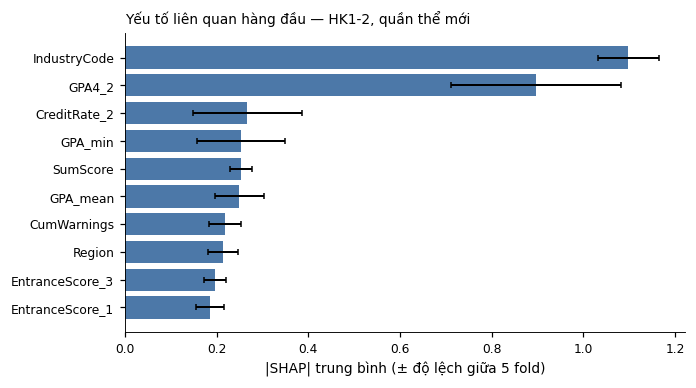

In [24]:
# Hình SHAP 1: mức ảnh hưởng trung bình (|SHAP|) của các đặc trưng hàng đầu
import os
ss = load_tab('shap_stability.csv').sort_values('mean_abs_shap', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ypos = np.arange(len(ss))[::-1]
ax.barh(ypos, ss['mean_abs_shap'], xerr=ss['sd'], color='#4C78A8', capsize=2)
ax.set_yticks(ypos); ax.set_yticklabels(ss['feature'], fontsize=8)
ax.set_xlabel('|SHAP| trung bình (± độ lệch giữa 5 fold)')
ax.set_title('Yếu tố liên quan hàng đầu — HK1-2, quần thể mới')
fig.tight_layout(); fig.savefig(os.path.join(FIGS, 'fig_shap_overview.png'))

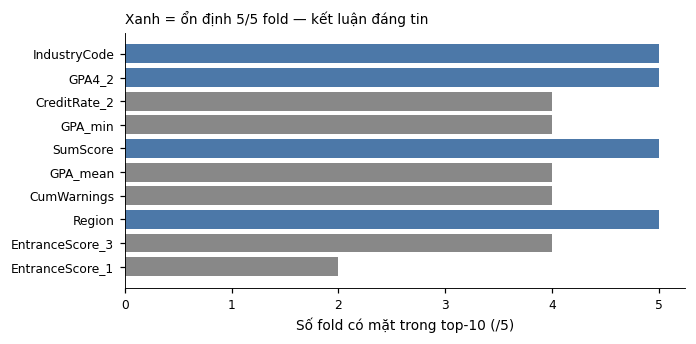

In [25]:
# Hình SHAP 2: độ ổn định — đặc trưng xuất hiện trong top-10 bao nhiêu / 5 fold
import os
ss = load_tab('shap_stability.csv').sort_values('mean_abs_shap', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ypos = np.arange(len(ss))[::-1]
colors = ['#4C78A8' if v == 5 else '#888888' for v in ss['top10_freq']]
ax.barh(ypos, ss['top10_freq'], color=colors)
ax.set_yticks(ypos); ax.set_yticklabels(ss['feature'], fontsize=8)
ax.set_xticks(range(6)); ax.set_xlabel('Số fold có mặt trong top-10 (/5)')
ax.set_title('Xanh = ổn định 5/5 fold — kết luận đáng tin')
fig.tight_layout(); fig.savefig(os.path.join(FIGS, 'fig_shap_stability.png'))

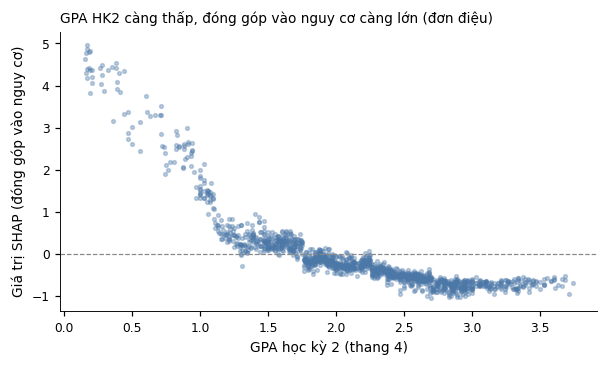

In [26]:
# Hình SHAP 3: quan hệ GPA học kỳ 2 → đóng góp vào nguy cơ (fold 1, tái lập seed 42)
import os
import shap
from sklearn.model_selection import StratifiedKFold
X2s, y2s, _ = dr.horizon_dataset(df, 2)
y2s = np.asarray(y2s)
tr, te = list(StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE).split(X2s, y2s))[0]
m = dr.make_lgbm(X2s); m.fit(X2s.iloc[tr], y2s[tr])
sv = shap.TreeExplainer(m).shap_values(X2s.iloc[te])
sv = sv[1] if isinstance(sv, list) else sv
j = list(X2s.columns).index('GPA4_2')
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.scatter(X2s.iloc[te, j], sv[:, j], s=6, alpha=0.35, color='#4C78A8')
ax.axhline(0, color='#888888', lw=0.8, ls='--')
ax.set_xlabel('GPA học kỳ 2 (thang 4)'); ax.set_ylabel('Giá trị SHAP (đóng góp vào nguy cơ)')
ax.set_title('GPA HK2 càng thấp, đóng góp vào nguy cơ càng lớn (đơn điệu)')
fig.tight_layout(); fig.savefig(os.path.join(FIGS, 'fig_shap_dependence_gpa2.png'))

## Bước 13 — Hệ thống cảnh báo sớm **hai tầng**

Kết quả nghiên cứu phải chuyển thành công cụ dùng được. Ta thiết kế **hệ thống cảnh báo hai tầng** trên
xác suất đã hiệu chỉnh (isotonic, HK1-2) — cân bằng giữa *bắt được nhiều ca* và *không làm phiền quá rộng*.
Điểm khác biệt so với bản cũ: các con số dưới đây tính trên **quần thể đúng** (sinh viên còn học tại cuối HK2,
tỷ lệ bỏ học nền 7,4%) — nên precision thấp hơn bảng cũ, nhưng là con số thật khi triển khai.

| Tầng | Ngưỡng | Recall | Precision | % gắn cờ | Hành động |
|---|---|---|---|---|---|
| **Tầng 1 — Sàng lọc rộng** | p ≥ 0,10 | 0,736 | 0,424 | 12,8% | Cố vấn học tập theo dõi, nhắc nhở |
| **Tầng 2 — Can thiệp sâu** | p ≥ 0,40 | 0,557 | 0,801 | 5,1% | Gặp trực tiếp, hỗ trợ tài chính/tâm lý |

**Ý tưởng:** Tầng 1 quét rộng để hạn chế bỏ sót; Tầng 2 độ chính xác cao (80%) dồn nguồn lực đắt cho nhóm
nguy cơ nhất. Ngưỡng chỉnh được theo ngân sách can thiệp từng trường — ô dưới in cả dải ngưỡng để lựa chọn.


In [27]:
cal = load_ckpt('calibration.pkl')
yv = np.asarray(cal['y']); p = np.asarray(cal['p_iso'])   # xác suất isotonic, HK1-2, quần thể mới
from sklearn.metrics import recall_score, precision_score
print(f'Quần thể: n={len(yv)} sinh viên còn học sau HK2 | tỷ lệ bỏ học nền = {yv.mean():.1%}')
print()
print(f'{"Ngưỡng":>8s}{"Recall":>9s}{"Precision":>11s}{"% gắn cờ":>10s}')
for thr in (0.10, 0.15, 0.20, 0.30, 0.40):
    pred = (p >= thr).astype(int)
    tag = '  << Tầng 1' if thr == 0.10 else ('  << Tầng 2' if thr == 0.40 else '')
    print(f'{thr:>8.2f}{recall_score(yv, pred):>9.3f}'
          f'{precision_score(yv, pred, zero_division=0):>11.3f}{pred.mean():>10.1%}{tag}')
print()
print('Chọn ngưỡng theo ngân sách: Tầng 1 (p>=0.10) quét rộng, Tầng 2 (p>=0.40)')
print('precision ~0.80 dồn nguồn lực đắt. So bản cũ: precision giảm vì base rate')
print('thật chỉ 7.4% (bản cũ 13% do lẫn người đã rời trường) — con số này mới là')
print('mức kỳ vọng đúng khi triển khai.')

Quần thể: n=7034 sinh viên còn học sau HK2 | tỷ lệ bỏ học nền = 7.4%

  Ngưỡng   Recall  Precision  % gắn cờ
    0.10    0.736      0.424     12.8%  << Tầng 1
    0.15    0.674      0.529      9.4%
    0.20    0.645      0.624      7.6%
    0.30    0.593      0.720      6.1%
    0.40    0.557      0.801      5.1%  << Tầng 2

Chọn ngưỡng theo ngân sách: Tầng 1 (p>=0.10) quét rộng, Tầng 2 (p>=0.40)
precision ~0.80 dồn nguồn lực đắt. So bản cũ: precision giảm vì base rate
thật chỉ 7.4% (bản cũ 13% do lẫn người đã rời trường) — con số này mới là
mức kỳ vọng đúng khi triển khai.


## Bước 14 — Kết luận và hướng mở rộng

**Ba câu hỏi ban đầu, giờ đã có trả lời — trên quần thể đo đúng bài toán triển khai:**

1. **Dự báo được không, sớm tới đâu?** — Được. Với sinh viên còn học sau **học kỳ 1**: AUC ~0,85
   (LightGBM tinh chỉnh, nested CV 0,8506 ± 0,0107); thêm **học kỳ 2**: ~0,92–0,93.
   Cảnh báo sớm khả thi và kịp can thiệp.
2. **Kết quả có đáng tin không?** — Có, và *trung thực*. Ba thuật toán cho hiệu năng rất gần nhau với
   khoảng tin cậy chồng lấn; sau hiệu chỉnh Holm chỉ **một** cặp đạt mức ý nghĩa sát ngưỡng
   (HK1: hồi quy logistic − Random Forest, p_holm ≈ 0,050), các cặp còn lại không có ý nghĩa thống kê.
   Xác suất được hiệu chỉnh tốt (ECE 0,0047 — *trong sàn nhiễu*, nghĩa là **không phát hiện sai lệch
   hiệu chỉnh**, không phải "hiệu chỉnh hoàn hảo"); bền theo thời gian (2020→2021 AUC 0,884
   [0,858–0,907]); và không phát hiện chênh lệch nhóm có ý nghĩa (các KTC chồng lấn).
3. **Yếu tố nào liên quan đến bỏ học?** — Ngành học, GPA học kỳ 2, tỷ lệ tín chỉ đạt, GPA thấp nhất và
   điểm đầu vào — ổn định qua 5 fold. (SHAP đo mức liên quan trong dự báo, **không kết luận nhân quả**.)

**Về tinh chỉnh siêu tham số.** Nested cross-validation cho thấy việc tối ưu siêu tham số của LightGBM
mang lại cải thiện khoảng **ΔAUC ≈ +0,007** so với cấu hình mặc định (0,8506 so với 0,8436 ở HK1), khi
được đánh giá theo một quy trình không thiên lệch. Do nghiên cứu **không** thực hiện quy trình "tinh chỉnh
phẳng" độc lập để đối chứng, **không đưa ra kết luận nào về mức optimism** của quy trình tinh chỉnh.

**Đóng góp phương pháp — điểm mạnh nhất của luận văn:** phát hiện và loại bỏ **rò rỉ nhãn theo thời điểm
dự báo** (Bước 5b): chứng minh bằng số rằng AUC 0,95 của bản cũ chủ yếu "phát hiện người đã đi"
(một cột GPA4_2 đơn lẻ đạt 0,956), rồi định nghĩa lại quần thể/nhãn theo horizon và chấp nhận con số
thấp hơn nhưng bảo vệ được. Kèm theo: khoảng tin cậy, kiểm định ý nghĩa, nested CV, hiệu chỉnh xác suất,
kiểm định thời gian, phân tích công bằng, độ ổn định SHAP.

**Một kết quả đáng chú ý về mặt phương pháp:** hồi quy logistic đạt AUC *cao hơn về mặt con số* so với
LightGBM ở cả hai tầm nhìn, dù khác biệt không có ý nghĩa thống kê. Điều này **củng cố** luận điểm trung
tâm: đóng góp của nghiên cứu nằm ở **khung phương pháp chống rò rỉ và đánh giá nghiêm ngặt**, không ở
việc chọn thuật toán. Khung này áp dụng được cho bất kỳ bộ phân loại nào.

**Giả định cần xác nhận với phòng đào tạo:** ngữ nghĩa `TermStatus` (cảnh báo học vụ *hay* đã nghỉ);
kết quả gần như không đổi khi bỏ hẳn biến này nên kết luận không phụ thuộc vào nó.

**Hướng mở rộng:** áp dụng cùng quy trình cho dữ liệu của trường đối tác ở nước khác (cần đồng bộ định
nghĩa cohort theo horizon như bản này), hiệu chỉnh ngưỡng theo bối cảnh và năng lực tư vấn của từng
trường, tích hợp cảnh báo tự động cuối mỗi học kỳ, và — như hướng nghiên cứu tiếp theo — đánh giá tác
động thực tế của can thiệp bằng thiết kế đối chứng hoặc mô hình uplift.